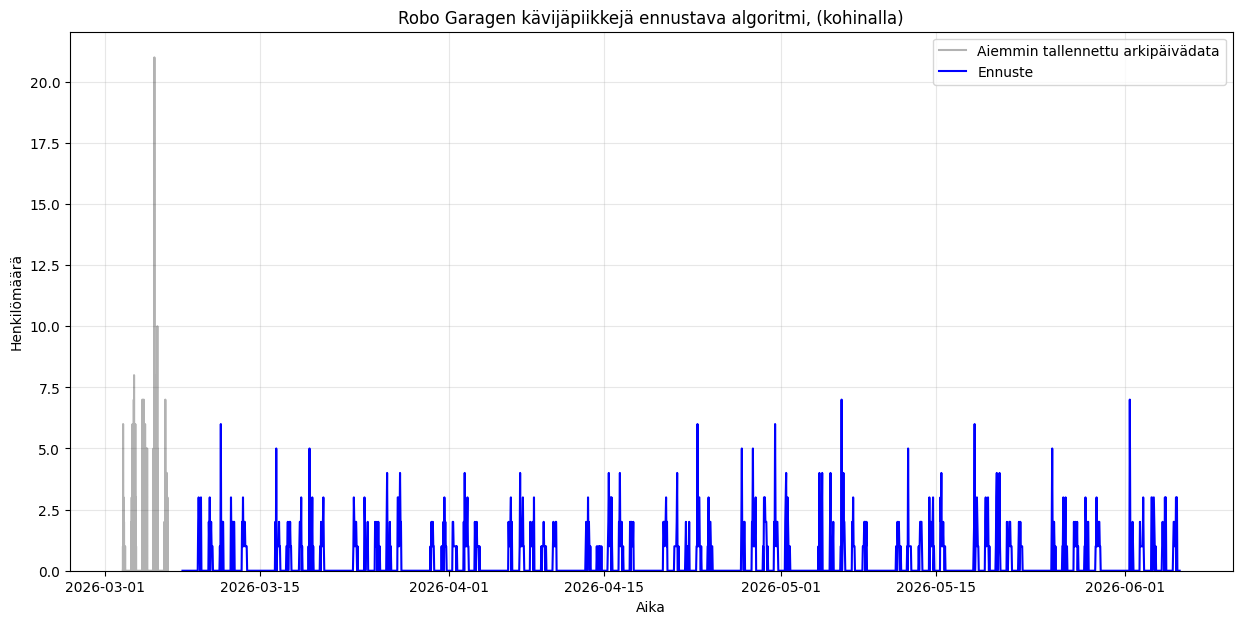

In [45]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

robo_data_url = 'https://raw.githubusercontent.com/rasmuali-droid/Projekti-3030/refs/heads/main/robo.data.json'
df = pd.read_json(robo_data_url)
payload_df = pd.json_normalize(df['payload'])
df = pd.concat([df.drop(columns=['payload']), payload_df], axis=1)

df['TimeStamp'] = pd.to_datetime(df['TimeStamp'], format='%d.%m.%Y klo %H.%M.%S', errors='coerce')
df = df.dropna(subset=['TimeStamp'])
df = df.sort_values(by='TimeStamp')

start_train = pd.to_datetime('2026-03-02 00:00:00')
end_train = pd.to_datetime('2026-03-07 23:59:59')
train_data_full = df[(df['TimeStamp'] >= start_train) & (df['TimeStamp'] <= end_train)].copy()

train_data_full['hour'] = train_data_full['TimeStamp'].dt.hour
train_data_full['day_of_week'] = train_data_full['TimeStamp'].dt.dayofweek

school_hours_data = train_data_full[
    (train_data_full['day_of_week'] <= 4) &
    (train_data_full['hour'] >= 8) &
    (train_data_full['hour'] <= 19)
]

hourly_profile = school_hours_data.groupby('hour')['person count'].mean().reindex(range(8, 20), fill_value=0)

hourly_std = school_hours_data.groupby('hour')['person count'].std().reindex(range(8, 20), fill_value=0)

hourly_std = hourly_std.fillna(0)


future_dates = pd.date_range(start='2026-03-08', periods=90*24, freq='h')
forecast_df = pd.DataFrame({'TimeStamp': future_dates})
forecast_df['hour'] = forecast_df['TimeStamp'].dt.hour
forecast_df['day_of_week'] = forecast_df['TimeStamp'].dt.dayofweek

def get_historical_prediction(row):
    if row['day_of_week'] <= 4 and 8 <= row['hour'] <= 19:
        return hourly_profile.get(row['hour'], 0)
    return 0

forecast_df['predicted_count_base'] = forecast_df.apply(get_historical_prediction, axis=1)

def add_realistic_noise(row):
    if row['day_of_week'] <= 4 and 8 <= row['hour'] <= 19:
        std_dev = hourly_std.get(row['hour'], 0)
        noise = np.random.normal(0, std_dev * 0.5)
        return max(0, round(row['predicted_count_base'] + noise))
    return round(row['predicted_count_base'])

forecast_df['predicted_count_realistic'] = forecast_df.apply(add_realistic_noise, axis=1)


plt.figure(figsize=(15, 7))
sns.lineplot(x='TimeStamp', y='person count', data=school_hours_data, label='Aiemmin tallennettu arkipäivädata', color='black', alpha=0.3)
sns.lineplot(x='TimeStamp', y='predicted_count_realistic', data=forecast_df, label='Ennuste', color='blue')

plt.title('Robo Garagen kävijäpiikkejä ennustava algoritmi, (kohinalla)')
plt.xlabel('Aika')
plt.ylabel('Henkilömäärä')
plt.ylim(bottom=0)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

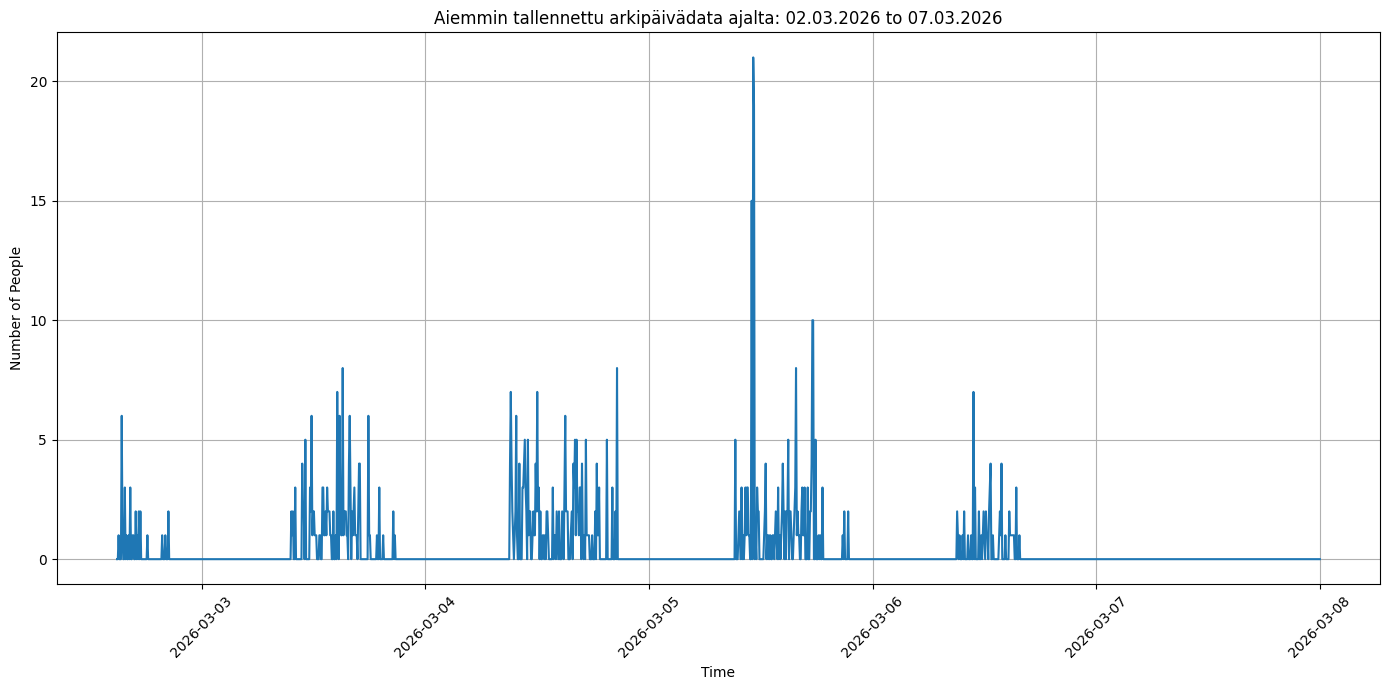

In [46]:
start_date = pd.to_datetime('02.03.2026 klo 00.00.00', format='%d.%m.%Y klo %H.%M.%S')
end_date = pd.to_datetime('07.03.2026 klo 23.59.59', format='%d.%m.%Y klo %H.%M.%S')

df['TimeStamp'] = pd.to_datetime(df['TimeStamp'], format='%d.%m.%Y klo %H.%M.%S', errors='coerce')

df_processed = df.dropna(subset=['TimeStamp'])

df_filtered = df_processed[(df_processed['TimeStamp'] >= start_date) & (df_processed['TimeStamp'] <= end_date)]

plt.figure(figsize=(14, 7))
sns.lineplot(x='TimeStamp', y='person count', data=df_filtered)
plt.title(f'Aiemmin tallennettu arkipäivädata ajalta: {start_date.strftime('%d.%m.%Y')} to {end_date.strftime('%d.%m.%Y')}')
plt.xlabel('Time')
plt.ylabel('Number of People')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

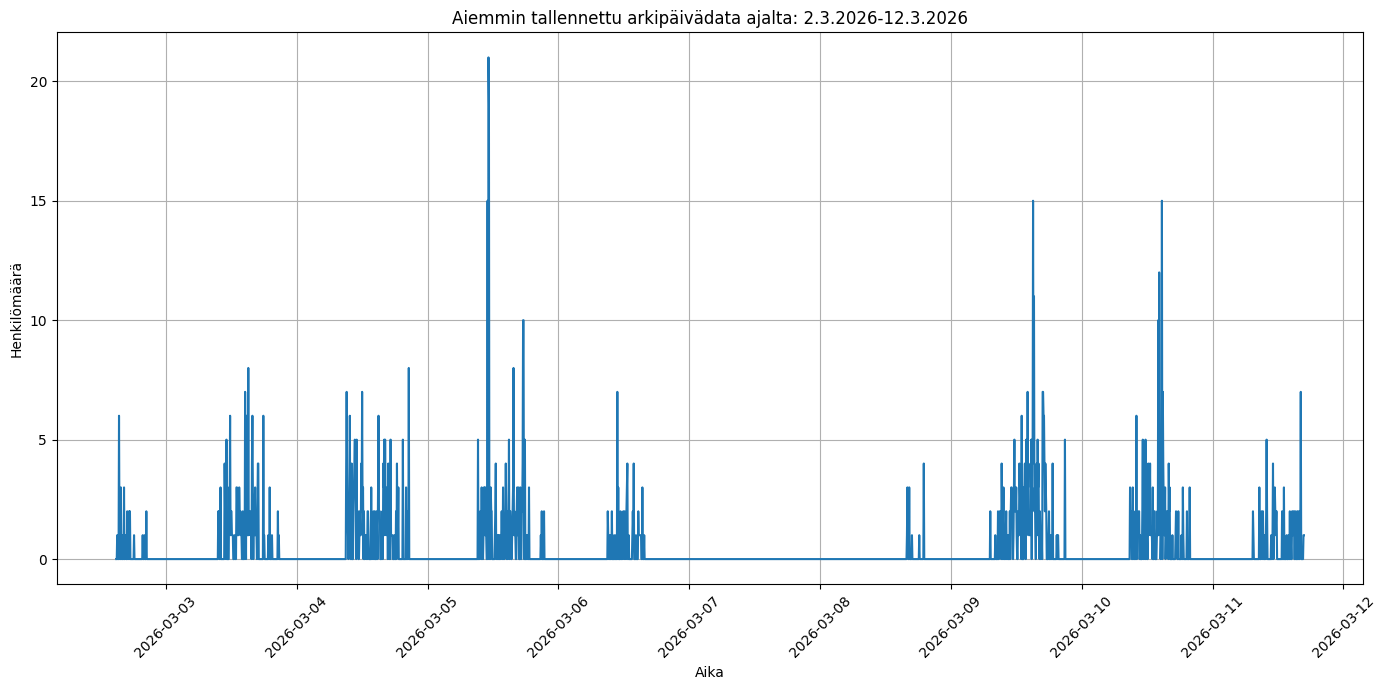

In [47]:
df['TimeStamp'] = pd.to_datetime(df['TimeStamp'], format='%d.%m.%Y klo %H.%M.%S')

df = df.sort_values(by='TimeStamp')

plt.figure(figsize=(14, 7))
sns.lineplot(x='TimeStamp', y='person count', data=df)
plt.title('Aiemmin tallennettu arkipäivädata ajalta: 2.3.2026-12.3.2026')
plt.xlabel('Aika')
plt.ylabel('Henkilömäärä')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Automaatio laboratorion Data

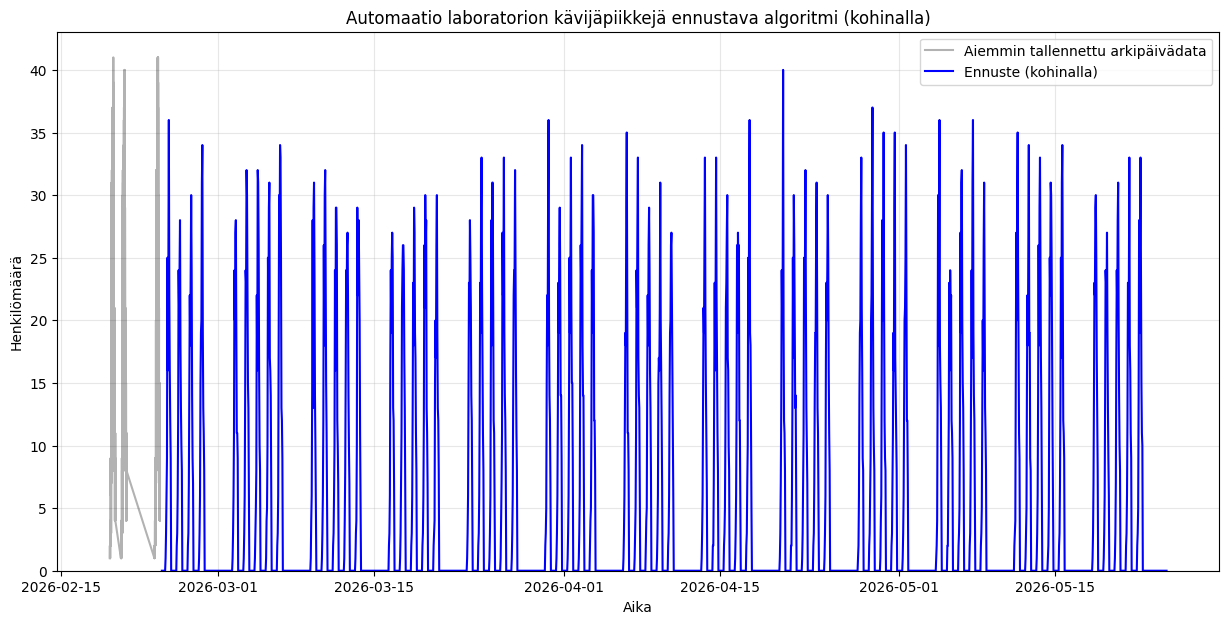

In [48]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

simulated_data_url = 'https://raw.githubusercontent.com/rasmuali-droid/Projekti-3030/refs/heads/main/simulated.data.json'
df_simulated = pd.read_json(simulated_data_url)
payload_df_simulated = pd.json_normalize(df_simulated['payload'])

cols_to_drop = ['payload']
if 'TimeStamp' in df_simulated.columns:
    cols_to_drop.append('TimeStamp')

df_simulated_base = df_simulated.drop(columns=cols_to_drop)

payload_df_simulated = payload_df_simulated.rename(columns={'Time': 'TimeStamp', 'pCount': 'person count'})

df_simulated = pd.concat([df_simulated_base, payload_df_simulated], axis=1)
df_simulated['TimeStamp'] = pd.to_datetime(df_simulated['TimeStamp'], format='%d %b %Y %H:%M:%S', errors='coerce')
df_simulated = df_simulated.dropna(subset=['TimeStamp'])
df_simulated = df_simulated.sort_values(by='TimeStamp')

start_train_simulated = pd.to_datetime('2026-02-17 00:00:00')
end_train_simulated = pd.to_datetime('2026-02-23 23:59:59')
train_data_full_simulated = df_simulated[(df_simulated['TimeStamp'] >= start_train_simulated) & (df_simulated['TimeStamp'] <= end_train_simulated)].copy()

train_data_full_simulated['hour'] = train_data_full_simulated['TimeStamp'].dt.hour
train_data_full_simulated['day_of_week'] = train_data_full_simulated['TimeStamp'].dt.dayofweek


school_hours_data_simulated = train_data_full_simulated[
    (train_data_full_simulated['day_of_week'] <= 4) &
    (train_data_full_simulated['hour'] >= 8) &
    (train_data_full_simulated['hour'] <= 19)
]


hourly_profile_simulated = school_hours_data_simulated.groupby('hour')['person count'].mean().reindex(range(8, 20), fill_value=0)
hourly_std_simulated = school_hours_data_simulated.groupby('hour')['person count'].std().reindex(range(8, 20), fill_value=0)
hourly_std_simulated = hourly_std_simulated.fillna(0)


future_dates_simulated = pd.date_range(start='2026-02-24', periods=90*24, freq='h')
forecast_df_simulated = pd.DataFrame({'TimeStamp': future_dates_simulated})
forecast_df_simulated['hour'] = forecast_df_simulated['TimeStamp'].dt.hour
forecast_df_simulated['day_of_week'] = forecast_df_simulated['TimeStamp'].dt.dayofweek

def get_historical_prediction_simulated(row):
    if row['day_of_week'] <= 4 and 8 <= row['hour'] <= 19:
        return hourly_profile_simulated.get(row['hour'], 0)
    return 0

forecast_df_simulated['predicted_count_base'] = forecast_df_simulated.apply(get_historical_prediction_simulated, axis=1)

def add_realistic_noise_simulated(row):
    if row['day_of_week'] <= 4 and 8 <= row['hour'] <= 19:
        std_dev = hourly_std_simulated.get(row['hour'], 0)
        noise = np.random.normal(0, std_dev * 0.5)
        return max(0, round(row['predicted_count_base'] + noise))
    return round(row['predicted_count_base'])

forecast_df_simulated['predicted_count_realistic'] = forecast_df_simulated.apply(add_realistic_noise_simulated, axis=1)


plt.figure(figsize=(15, 7))
sns.lineplot(x='TimeStamp', y='person count', data=school_hours_data_simulated, label='Aiemmin tallennettu arkipäivädata', color='black', alpha=0.3)
sns.lineplot(x='TimeStamp', y='predicted_count_realistic', data=forecast_df_simulated, label='Ennuste (kohinalla)', color='blue')

plt.title('Automaatio laboratorion kävijäpiikkejä ennustava algoritmi (kohinalla)')
plt.xlabel('Aika')
plt.ylabel('Henkilömäärä')
plt.ylim(bottom=0)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()